In [4]:
import os
import re
import json
from datasets import load_dataset

# 1. Fetch original LongBench-v2 metadata for difficulty & length buckets
print("Loading base LongBench-v2 dataset to extract metadata...")
base_ds = load_dataset("THUDM/LongBench-v2", split="train")

# Build a lookup table keyed by the prompt/question or an id if available
metadata_map = {}
for row in base_ds:
    # Use the question as a deterministic lookup key
    key = row.get("_id") or row.get("question", "").strip()
    metadata_map[key] = {
        "answer": row["answer"].strip(),
        "difficulty": row.get("difficulty", "hard"),
        "length": row.get("length", "long"),
    }

# 2. Extract multiple-choice letters from model generations
def extract_choice(pred_text: str) -> str:
    if not pred_text:
        return ""
    # Look for explicit answers like "Answer: A", "The correct answer is (B)", or standalone letters
    match = re.search(r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b", pred_text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    # Fallback: scan for the first isolated capital choice letter
    letters = re.findall(r"\b([A-D])\b", pred_text)
    return letters[0].upper() if letters else ""

# 3. Path to your benchmark runs
runs_dirs = {
    "santapp": "../benchmarks/longbench/sdpa",
    # "hierarchical": "/workspace/runs/longbench-hierarchical",
}

output = ["Model\tOverall\tEasy\tHard\tShort\tMedium\tLong"]
compensated = False

for model_name, run_dir in runs_dirs.items():
    pred_dir = os.path.join(run_dir, "predictions", model_name)
    if not os.path.exists(pred_dir):
        # Fallback to general predictions folder
        pred_dir = os.path.join(run_dir, "predictions")
        if not os.path.exists(pred_dir):
            print(f"Skipping {model_name}: prediction directory not found at {pred_dir}")
            continue

    # Load all json/jsonl prediction entries written by the harness
    pred_records = []
    for fname in os.listdir(pred_dir):
        if fname.endswith(".jsonl") or fname.endswith(".json"):
            fpath = os.path.join(pred_dir, fname)
            with open(fpath, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if line:
                        pred_records.append(json.loads(line))

    if not pred_records:
        print(f"No predictions found for {model_name}.")
        continue

    easy, hard, short, medium, long = 0, 0, 0, 0, 0
    easy_acc, hard_acc, short_acc, medium_acc, long_acc = 0.0, 0.0, 0.0, 0.0, 0.0

    for item in pred_records:
        raw_pred = item.get("prediction", "")
        extracted_pred = extract_choice(raw_pred)
        
        # Match against metadata
        ref_answers = item.get("references") or item.get("outputs", [])
        ground_truth = ref_answers[0].strip() if ref_answers else ""
        
        # Look up difficulty and length from the mapping if missing
        lookup_key = item.get("id") or item.get("question", "").strip()
        meta = metadata_map.get(lookup_key, {})
        difficulty = item.get("difficulty") or meta.get("difficulty", "hard")
        length = item.get("length") or meta.get("length", "long")
        if not ground_truth:
            ground_truth = meta.get("answer", "")

        judge = 1.0 if (extracted_pred and extracted_pred == ground_truth.upper()) else 0.0
        if compensated and not extracted_pred:
            judge = 0.25

        if difficulty == "easy":
            easy += 1
            easy_acc += judge
        else:
            hard += 1
            hard_acc += judge

        if length == "short":
            short += 1
            short_acc += judge
        elif length == "medium":
            medium += 1
            medium_acc += judge
        else:
            long += 1
            long_acc += judge

    total = len(pred_records)
    overall = round(100.0 * (easy_acc + hard_acc) / total, 1) if total else 0.0
    easy_score = round(100.0 * easy_acc / easy, 1) if easy else 0.0
    hard_score = round(100.0 * hard_acc / hard, 1) if hard else 0.0
    short_score = round(100.0 * short_acc / short, 1) if short else 0.0
    medium_score = round(100.0 * medium_acc / medium, 1) if medium else 0.0
    long_score = round(100.0 * long_acc / long, 1) if long else 0.0

    output.append(
        f"{model_name}\t{overall}\t{easy_score}\t{hard_score}\t{short_score}\t{medium_score}\t{long_score}"
    )

with open("result.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(output))

print("\n".join(output))

Loading base LongBench-v2 dataset to extract metadata...
No predictions found for santapp.
Model	Overall	Easy	Hard	Short	Medium	Long


In [6]:
import json
import re
from collections import Counter

JSONL_PATH = "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"  # Path to your jsonl file

records = []
with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

total = len(records)
ruler_scores = []
extracted_matches = 0

def extract_choice(text: str) -> str:
    # Look for patterns like "The correct answer is A", "B)", or standalone A-D
    match = re.search(r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b", text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    letters = re.findall(r"\b([A-D])\b", text)
    return letters[0].upper() if letters else ""

for r in records:
    # 1. Harness RULER score (substring match)
    ruler_scores.append(r.get("metrics", {}).get("example_ruler_score", 0.0))
    
    # 2. Strict LongBench MC extraction
    target = r["outputs"][0].strip().upper()
    pred_letter = extract_choice(r.get("pred", ""))
    if pred_letter == target:
        extracted_matches += 1

ruler_acc = sum(ruler_scores) / total if total else 0.0
strict_acc = (extracted_matches / total) * 100.0 if total else 0.0

summary = {
    "task": records[0]["task"] if records else "unknown",
    "backend": records[0]["metrics"]["backend"] if records else "unknown",
    "num_examples": total,
    "ruler_string_match_score": round(ruler_acc, 2),
    "extracted_mc_accuracy": round(strict_acc, 2),
    "mean_prefill_seconds": round(sum(r["metrics"]["prefill_seconds"] for r in records) / total, 3),
    "mean_decode_seconds": round(sum(r["metrics"]["decode_seconds"] for r in records) / total, 3),
    "mean_kv_access_pct": round(sum(r["metrics"]["decode_gqa_kv_access_pct"] for r in records) / total, 1),
}

print(json.dumps(summary, indent=2))

with open("reconstructed_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

{
  "task": "longbench_v2_cot",
  "backend": "sdpa",
  "num_examples": 106,
  "ruler_string_match_score": 98.11,
  "extracted_mc_accuracy": 25.47,
  "mean_prefill_seconds": 5.721,
  "mean_decode_seconds": 1.631,
  "mean_kv_access_pct": 100.0
}


In [8]:
import json
import os
import re
from datasets import load_dataset

# 1. Load original LongBench-v2 to obtain 'difficulty' and 'length' metadata
print("Fetching LongBench-v2 metadata...")
lb_dataset = load_dataset("THUDM/LongBench-v2", split="train")
meta_lookup = {}
for item in lb_dataset:
    # Key by prompt question or index
    meta_lookup[item.get("_id", "")] = {
        "difficulty": item.get("difficulty", "hard"),
        "length": item.get("length", "long"),
        "answer": item.get("answer", "").strip().upper()
    }

def extract_mc_choice(pred_text: str) -> str:
    if not pred_text:
        return ""
    # Look for explicit answer declaration first
    match = re.search(r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b", pred_text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    # Fallback to the last isolated option letter mentioned in the text
    matches = re.findall(r"\b([A-D])\b", pred_text)
    return matches[-1].upper() if matches else ""

def convert_harness_to_grader_format(input_jsonl: str, output_dir: str = "results"):
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.basename(input_jsonl)
    output_path = os.path.join(output_dir, filename)

    converted_rows = []
    with open(input_jsonl, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            entry = json.loads(line.strip())
            
            pred_text = entry.get("pred", "")
            extracted = extract_mc_choice(pred_text)
            
            ground_truth = entry.get("outputs", [""])[0].strip().upper()
            
            # Map index/id to metadata lookup
            idx = entry.get("index", entry.get("others", {}).get("id"))
            meta = meta_lookup.get(str(idx), {})
            
            if not ground_truth and "answer" in meta:
                ground_truth = meta["answer"]

            judge = 1 if (extracted and extracted == ground_truth) else 0

            converted_rows.append({
                "pred": extracted if extracted else None,
                "judge": judge,
                "difficulty": meta.get("difficulty", "hard"),
                "length": meta.get("length", "long")
            })

    with open(output_path, "w", encoding="utf-8") as out:
        json.dump(converted_rows, out, indent=2)

    print(f"Saved {len(converted_rows)} records to {output_path}")

# Run conversion on your file
convert_harness_to_grader_format("../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl", output_dir="results")

Fetching LongBench-v2 metadata...
Saved 106 records to results\longbench_v2_cot.jsonl


In [9]:
from datasets import load_dataset
from collections import Counter

# Load your exact processed repo
ds = load_dataset("MrBigBrane/LongBench-v2-32k-CoT", "longbench_v2_cot", split="train")

print("Columns in your dataset:", ds.column_names)
print("Total examples:", len(ds))

# Check if original metadata columns exist
if "difficulty" in ds.column_names and "length" in ds.column_names:
    print("Difficulty counts:", Counter(ds["difficulty"]))
    print("Length counts:", Counter(ds["length"]))
else:
    # Check what the original 106 samples actually map to in base LongBench-v2
    base_ds = load_dataset("THUDM/LongBench-v2", split="train")
    
    # Match by ground-truth answer + first 100 characters of the context text
    base_lookup = {}
    for row in base_ds:
        # Create a content-based signature
        sig = row["context"][:80].strip()
        base_lookup[sig] = {
            "difficulty": row.get("difficulty"),
            "length": row.get("length")
        }

    matched_diff = []
    matched_len = []
    for row in ds:
        matched = False
        for sig, meta in base_lookup.items():
            if sig in row["input"]:
                matched_diff.append(meta["difficulty"])
                matched_len.append(meta["length"])
                matched = True
                break
        if not matched:
            matched_diff.append("unmatched")
            matched_len.append("unmatched")

    print("Actual difficulty distribution in your 106 samples:", Counter(matched_diff))
    print("Actual length distribution in your 106 samples:", Counter(matched_len))

c:\CondaEnvs\opus-ai\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\theep\.cache\huggingface\hub\datasets--MrBigBrane--LongBench-v2-32k-CoT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 106/106 [00:00<00:00, 3021.48 examples/s]


Columns in your dataset: ['input', 'outputs']
Total examples: 106
Actual difficulty distribution in your 106 samples: Counter({'hard': 53, 'easy': 53})
Actual length distribution in your 106 samples: Counter({'short': 80, 'medium': 26})


In [12]:
import json
import os
import re
from collections import Counter
from datasets import load_dataset

print("1. Loading base THUDM/LongBench-v2 dataset to build ground truth lookup...")
base_ds = load_dataset("THUDM/LongBench-v2", split="train")

# Build a prefix lookup map from the original dataset context
base_lookup = []
for row in base_ds:
    ctx = row["context"].strip()
    prefix = ctx[:120] if len(ctx) >= 120 else ctx
    base_lookup.append({
        "prefix": prefix,
        "difficulty": row.get("difficulty"),
        "length": row.get("length"),
        "answer": row.get("answer", "").strip().upper()
    })

def extract_mc_choice(pred_text: str) -> str:
    if not pred_text:
        return ""
    # Look for explicit declaration like "The correct answer is A", "Answer: B", "option C"
    match = re.search(r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b", pred_text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    # Fallback: find the first isolated capital choice letter
    matches = re.findall(r"\b([A-D])\b", pred_text)
    return matches[0].upper() if matches else ""

def find_metadata_for_input(input_text: str):
    for entry in base_lookup:
        if entry["prefix"] in input_text:
            return entry["difficulty"], entry["length"], entry["answer"]
    return None, None, None

# Load your 106 inputs once to map sample indices to their true metadata
print("2. Mapping 106-sample dataset metadata...")
my_ds = load_dataset("MrBigBrane/LongBench-v2-32k-CoT", "longbench_v2_cot", split="train")
sample_meta = {}

for i, row in enumerate(my_ds):
    diff, length, ans = find_metadata_for_input(row["input"])
    if not diff:
        # Fallback: check against question text
        for entry in base_lookup:
            if entry["answer"] in row.get("outputs", []):
                diff, length, ans = entry["difficulty"], entry["length"], entry["answer"]
                break
    sample_meta[i] = {
        "difficulty": diff if diff else "easy",
        "length": length if length else "short",
        "answer": row["outputs"][0].strip().upper() if row.get("outputs") else ans
    }

print("Verified Sample Metadata Counts:")
print("Difficulty:", Counter(v["difficulty"] for v in sample_meta.values()))
print("Length:", Counter(v["length"] for v in sample_meta.values()))

# Process files in results/
output = ["Model\tOverall\tEasy\tHard\tShort\tMedium\tLong"]
# Specify individual file paths or a list of runs to evaluate
target_files = {
    "sdpa": "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl",
    # Add your other runs once available:
    # "santapp": "../benchmarks/longbench/santapp/predictions/santapp/longbench_v2_cot.jsonl",
    # "hierarchical": "../benchmarks/longbench/hierarchical/predictions/hierarchical/longbench_v2_cot.jsonl",
}

for name, filepath in target_files.items():
    if not os.path.exists(filepath):
        print(f"Skipping {name}: file not found at {filepath}")
        continue

    pred_data = []
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read().strip()
        if not content:
            continue
        
        # Determine whether the file is a single JSON document or line-delimited JSONL
        if content.startswith("["):
            pred_data = json.loads(content)
        elif content.startswith("{") and "\n{" not in content:
            # Single object or summary file
            pred_data = [json.loads(content)]
        else:
            # Standard JSONL: line-by-line
            for line in content.splitlines():
                line = line.strip()
                if line:
                    pred_data.append(json.loads(line))

    easy, hard, short, medium, long = 0, 0, 0, 0, 0
    easy_acc, hard_acc, short_acc, medium_acc, long_acc = 0.0, 0.0, 0.0, 0.0, 0.0

    for pred in pred_data:
        idx = pred.get("index", pred.get("others", {}).get("source_position", pred.get("others", {}).get("id")))
        meta = sample_meta.get(idx, {"difficulty": "hard", "length": "short", "answer": ""})
        
        target = pred.get("outputs", [meta["answer"]])[0].strip().upper()
        raw_pred = pred.get("pred", "")
        extracted = extract_mc_choice(raw_pred)
        
        judge = 1.0 if (extracted and extracted == target) else 0.0

        if meta["difficulty"] == "easy":
            easy += 1
            easy_acc += judge
        else:
            hard += 1
            hard_acc += judge

        if meta["length"] == "short":
            short += 1
            short_acc += judge
        elif meta["length"] == "medium":
            medium += 1
            medium_acc += judge
        else:
            long += 1
            long_acc += judge

    total = len(pred_data)
    overall_pct = round(100 * (easy_acc + hard_acc) / total, 1) if total else 0.0
    easy_pct = round(100 * easy_acc / easy, 1) if easy else 0.0
    hard_pct = round(100 * hard_acc / hard, 1) if hard else 0.0
    short_pct = round(100 * short_acc / short, 1) if short else 0.0
    medium_pct = round(100 * medium_acc / medium, 1) if medium else 0.0
    long_pct = round(100 * long_acc / long, 1) if long else 0.0

    output.append(f"{name}\t{overall_pct}\t{easy_pct}\t{hard_pct}\t{short_pct}\t{medium_pct}\t{long_pct}")

scorecard = "\n".join(output)
print("\n" + scorecard)
with open("result.txt", "w", encoding="utf-8") as f:
    f.write(scorecard)

1. Loading base THUDM/LongBench-v2 dataset to build ground truth lookup...
2. Mapping 106-sample dataset metadata...
Verified Sample Metadata Counts:
Difficulty: Counter({'hard': 67, 'easy': 39})
Length: Counter({'short': 106})

Model	Overall	Easy	Hard	Short	Medium	Long
sdpa	25.5	33.3	20.9	25.5	0.0	0.0


In [14]:
import json
from collections import Counter
from datasets import load_dataset
import difflib

print("1. Loading datasets...")
base_ds = load_dataset("THUDM/LongBench-v2", split="train")
my_ds = load_dataset("MrBigBrane/LongBench-v2-32k-CoT", "longbench_v2_cot", split="train")

# Prepare base dataset records
base_records = []
for idx, row in enumerate(base_ds):
    # Extract distinct text pieces to test
    q = row.get("question", "").strip()
    # First 150 chars of context
    ctx_prefix = row.get("context", "")[:150].strip()
    base_records.append({
        "base_idx": idx,
        "question": q,
        "ctx_prefix": ctx_prefix,
        "difficulty": row.get("difficulty"),
        "length": row.get("length"),
        "answer": row.get("answer", "").strip().upper(),
        "id": row.get("_id", "")
    })

verified_mapping = {}
failed_indices = []

print("2. Running fuzzy anchor matching across 106 samples...")
for i, row in enumerate(my_ds):
    prompt_text = row["input"]
    target_answer = row["outputs"][0].strip().upper()

    best_match = None
    best_score = 0.0

    for item in base_records:
        # Ground truth must match
        if item["answer"] != target_answer:
            continue

        # Check question containment or similarity
        q = item["question"]
        if q and q in prompt_text:
            best_match = item
            break
        
        # Check context prefix containment
        if item["ctx_prefix"] and item["ctx_prefix"] in prompt_text:
            best_match = item
            break

        # Fallback: check character overlap of question if it had minor formatting changes
        if q and len(q) > 20:
            # Check 30-char slice from middle of the question
            mid = len(q) // 2
            probe = q[mid-15:mid+15]
            if probe in prompt_text:
                best_match = item
                break

    if best_match:
        verified_mapping[i] = {
            "index": i,
            "difficulty": best_match["difficulty"],
            "length": best_match["length"],
            "answer": best_match["answer"],
            "id": best_match["id"],
            "base_idx": best_match["base_idx"]
        }
    else:
        failed_indices.append(i)

if failed_indices:
    print(f"\nStill could not match {len(failed_indices)} indices: {failed_indices}")
    print("\n--- Inspecting first failing index ---")
    fail_idx = failed_indices[0]
    sample_text = my_ds[fail_idx]["input"]
    print(f"Sample {fail_idx} first 300 chars:")
    print(sample_text[:300])
    print(f"Sample {fail_idx} last 300 chars:")
    print(sample_text[-300:])
    print(f"Target Answer: {my_ds[fail_idx]['outputs']}")
else:
    print("\n=== SUCCESS: ALL 106/106 MATCHED ===")
    diff_counts = Counter(item["difficulty"] for item in verified_mapping.values())
    len_counts = Counter(item["length"] for item in verified_mapping.values())
    print("Difficulty Distribution:", diff_counts)
    print("Length Distribution:    ", len_counts)

    with open("ground_truth_metadata_106.json", "w", encoding="utf-8") as f:
        json.dump(verified_mapping, f, indent=2)
    print("Saved to ground_truth_metadata_106.json")

1. Loading datasets...
2. Running fuzzy anchor matching across 106 samples...

=== SUCCESS: ALL 106/106 MATCHED ===
Difficulty Distribution: Counter({'hard': 73, 'easy': 33})
Length Distribution:     Counter({'short': 103, 'medium': 3})
Saved to ground_truth_metadata_106.json


In [16]:
import json
import os
import re

# Load the verified ground truth lookup table
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
    meta_lookup = {int(k): v for k, v in json.load(f).items()}

def extract_mc_choice(pred_text: str) -> str:
    if not pred_text:
        return ""
    # 1. Look for explicit declarations: "The correct answer is (A)", "Answer: B", "option C"
    match = re.search(
        r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b",
        pred_text,
        re.IGNORECASE,
    )
    if match:
        return match.group(1).upper()
    # 2. Look for standalone option patterns like "\n\nB)" or "(C)"
    match_paren = re.search(r"(?:\n|\A)\s*(?:\()?([A-D])\)", pred_text)
    if match_paren:
        return match_paren.group(1).upper()
    # 3. Fallback: match the last isolated choice letter mentioned
    matches = re.findall(r"\b([A-D])\b", pred_text)
    return matches[-1].upper() if matches else ""

target_runs = {
    # "sdpa": "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl",
    # "santapp": "../benchmarks/longbench/santapp/predictions/santapp/longbench_v2_cot.jsonl",
    "hierarchical": "../benchmarks/longbench/hierarchical/predictions/hierarchical/longbench_v2_cot.jsonl",
}

output = ["Model\tOverall\tEasy\tHard\tShort\tMedium\tLong"]

for name, filepath in target_runs.items():
    if not os.path.exists(filepath):
        print(f"Skipping {name}: file not found at {filepath}")
        continue

    pred_data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                pred_data.append(json.loads(line))

    easy, hard, short, medium, long = 0, 0, 0, 0, 0
    easy_acc, hard_acc, short_acc, medium_acc, long_acc = (
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    )

    for pred in pred_data:
        idx = pred.get(
            "index",
            pred.get(
                "others",
                {}).get(
                    "source_position",
                    pred.get("others",
                             {}).get("id")),
        )
        meta = meta_lookup[idx]

        target = meta["answer"]
        raw_pred = pred.get("pred", "")
        extracted = extract_mc_choice(raw_pred)

        judge = 1.0 if (extracted and extracted == target) else 0.0

        if meta["difficulty"] == "easy":
            easy += 1
            easy_acc += judge
        else:
            hard += 1
            hard_acc += judge

        if meta["length"] == "short":
            short += 1
            short_acc += judge
        elif meta["length"] == "medium":
            medium += 1
            medium_acc += judge
        else:
            long += 1
            long_acc += judge

    total = len(pred_data)
    overall_pct = (
        round(100 * (easy_acc + hard_acc) / total, 1) if total else 0.0
    )
    easy_pct = round(100 * easy_acc / easy, 1) if easy else 0.0
    hard_pct = round(100 * hard_acc / hard, 1) if hard else 0.0
    short_pct = round(100 * short_acc / short, 1) if short else 0.0
    medium_pct = round(100 * medium_acc / medium, 1) if medium else 0.0
    long_pct = round(100 * long_acc / long, 1) if long else 0.0

    output.append(
        f"{name}\t{overall_pct}\t{easy_pct}\t{hard_pct}\t{short_pct}\t{medium_pct}\t{long_pct}"
    )

report = "\n".join(output)
print("\n" + report)

with open("result.txt", "w", encoding="utf-8") as f:
    f.write(report)


Model	Overall	Easy	Hard	Short	Medium	Long
hierarchical	29.2	42.4	23.3	29.1	33.3	0.0


In [7]:
import json
import os
import re

# Load verified canonical metadata mapping (73 Hard / 33 Easy)
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
  meta_lookup = {int(k): v for k, v in json.load(f).items()}


def extract_strict_mc_choice(pred_text: str) -> str:
  """Strictly extracts the multiple choice letter (A, B, C, or D).

  Prioritizes the exact 'Final Answer:' anchor and rejects ambiguous
  multi-letter outputs like '[B/C]'.
  """
  if not pred_text:
    return ""

  # 1. Primary Target: Strict 'Final Answer: [X]' or 'Final Answer: X'
  final_match = re.search(
      r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
      pred_text,
      re.IGNORECASE,
  )
  if final_match:
    # Reject ambiguous choices like [B/C] or [A or B] right after the anchor
    post_match_slice = pred_text[final_match.start() : final_match.end() + 10]
    if re.search(
        r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
        post_match_slice,
        re.IGNORECASE,
    ):
      return ""  # Ambiguous guess, do not reward
    return final_match.group(1).upper()

  # 2. Secondary Target: Explicit "The correct answer is (X)" or "Answer: X"
  explicit_match = re.search(
      r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
      pred_text,
      re.IGNORECASE,
  )
  if explicit_match:
    return explicit_match.group(1).upper()

  # 3. Tertiary Target: Standalone option declaration on the final lines
  tail_matches = re.findall(
      r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
  )
  if tail_matches:
    return tail_matches[-1].upper()

  return ""


target_runs = {
    # "sdpa": "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl",
    # "santapp": "../benchmarks/longbench/santapp/predictions/santapp/longbench_v2_cot.jsonl",
    "sdpa": (
        "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"
    ),
    "hierarchical-128": (
        "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"
    ),
    "hierarchical-256": (
        "../benchmarks/longbench/hierarchical/256/predictions/hierarchical/longbench_v2_cot.jsonl"
    ),
    "hierarchical-512": (
        "../benchmarks/longbench/hierarchical/512/predictions/hierarchical/longbench_v2_cot.jsonl"
    ),
}

output = [
    "Model\tOverall\tEasy\tHard\tShort\tMedium\tLong\tExtracted_Rate\tCorrect/Total"
]

for name, filepath in target_runs.items():
  if not os.path.exists(filepath):
    print(f"Skipping {name}: file not found at {filepath}")
    continue

  pred_data = []
  with open(filepath, "r", encoding="utf-8") as f:
    for line in f:
      line = line.strip()
      if line:
        pred_data.append(json.loads(line))

  easy, hard, short, medium, long = 0, 0, 0, 0, 0
  easy_acc, hard_acc, short_acc, medium_acc, long_acc = (
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
  )
  extracted_count = 0
  total_correct = 0

  for pred in pred_data:
    idx = pred.get(
        "index",
        pred.get("others", {}).get(
            "source_position", pred.get("others", {}).get("id")
        ),
    )
    meta = meta_lookup[idx]

    target = meta["answer"]
    raw_pred = pred.get("pred", "")
    choice = extract_strict_mc_choice(raw_pred)

    if choice:
      extracted_count += 1
      is_correct = choice == target
      judge = 1.0 if is_correct else 0.0
      if is_correct:
        total_correct += 1
    else:
      judge = 0.0

    if meta["difficulty"] == "easy":
      easy += 1
      easy_acc += judge
    else:
      hard += 1
      hard_acc += judge

    if meta["length"] == "short":
      short += 1
      short_acc += judge
    elif meta["length"] == "medium":
      medium += 1
      medium_acc += judge
    else:
      long += 1
      long_acc += judge

  total = len(pred_data)
  overall_pct = round(100 * (easy_acc + hard_acc) / total, 1) if total else 0.0
  easy_pct = round(100 * easy_acc / easy, 1) if easy else 0.0
  hard_pct = round(100 * hard_acc / hard, 1) if hard else 0.0
  short_pct = round(100 * short_acc / short, 1) if short else 0.0
  medium_pct = round(100 * medium_acc / medium, 1) if medium else 0.0
  long_pct = round(100 * long_acc / long, 1) if long else 0.0
  extract_pct = round(100 * extracted_count / total, 1) if total else 0.0

  output.append(
      f"{name}\t{overall_pct}\t{easy_pct}\t{hard_pct}\t{short_pct}\t{medium_pct}\t{long_pct}\t{extract_pct}%\t{total_correct}/{total}"
  )

report = "\n".join(output)
print("\n" + report)

with open("result.txt", "w", encoding="utf-8") as f:
  f.write(report)


Model	Overall	Easy	Hard	Short	Medium	Long	Extracted_Rate	Correct/Total
sdpa	35.8	54.5	27.4	34.0	100.0	0.0	96.2%	38/106
hierarchical-128	33.0	48.5	26.0	31.1	100.0	0.0	96.2%	35/106
hierarchical-256	37.7	48.5	32.9	35.9	100.0	0.0	97.2%	40/106
hierarchical-512	37.7	48.5	32.9	36.9	66.7	0.0	94.3%	40/106


In [11]:
import json

filepath = "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"

with open(filepath, "r", encoding="utf-8") as f:
  for line in f:
    item = json.loads(line)
    pred_text = item.get("pred", "")
    idx = item.get("index")

    # If strict extractor returned empty string
    if not extract_strict_mc_choice(pred_text):
      print(f"=== UNEXTRACTED SAMPLE {idx} ===")
      print(f"Tokens Generated: {item.get('metrics', {}).get('generated_tokens')}")
      print(f"Tail of pred:\n...{pred_text[-250:]}\n")

=== UNEXTRACTED SAMPLE 59 ===
Tokens Generated: 256
Tail of pred:
...es (400 + 400 + 300), and Copy 2 uses 1100 bytes (400 + 300 + 400), which also exceeds the total available storage.

Option C: Copy 1 uses 1100 bytes (400 + 200 + 500), and Copy 2 uses 1100 bytes (300 + 300 + 500), which fits the available storage.



=== UNEXTRACTED SAMPLE 42 ===
Tokens Generated: 256
Tail of pred:
... 9 + 9 + 9 + 9 + 9 + 9 + 9 + 9 + 9 + 9 = 180
- Player_4: 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 = 180
- Player_7: 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10

=== UNEXTRACTED SAMPLE 19 ===
Tokens Generated: 256
Tail of pred:
... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
- player_4: 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
- player_6: 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
- player_8: 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

=== UNEXTRACTED SAMPLE 47 ===
Tokens 

Hierarchical (S=128)     | Accuracy:  33.0% [95% CI:  24.5%,  42.5%] | Access:  15.0%
Hierarchical (S=256)     | Accuracy:  37.7% [95% CI:  28.3%,  47.2%] | Access:  17.2%
Hierarchical (S=512)     | Accuracy:  37.7% [95% CI:  29.2%,  47.2%] | Access:  21.2%
SDPA (Dense)             | Accuracy:  35.8% [95% CI:  27.4%,  45.3%] | Access: 100.0%

Plot saved successfully to accuracy_vs_memory_access_ci.png


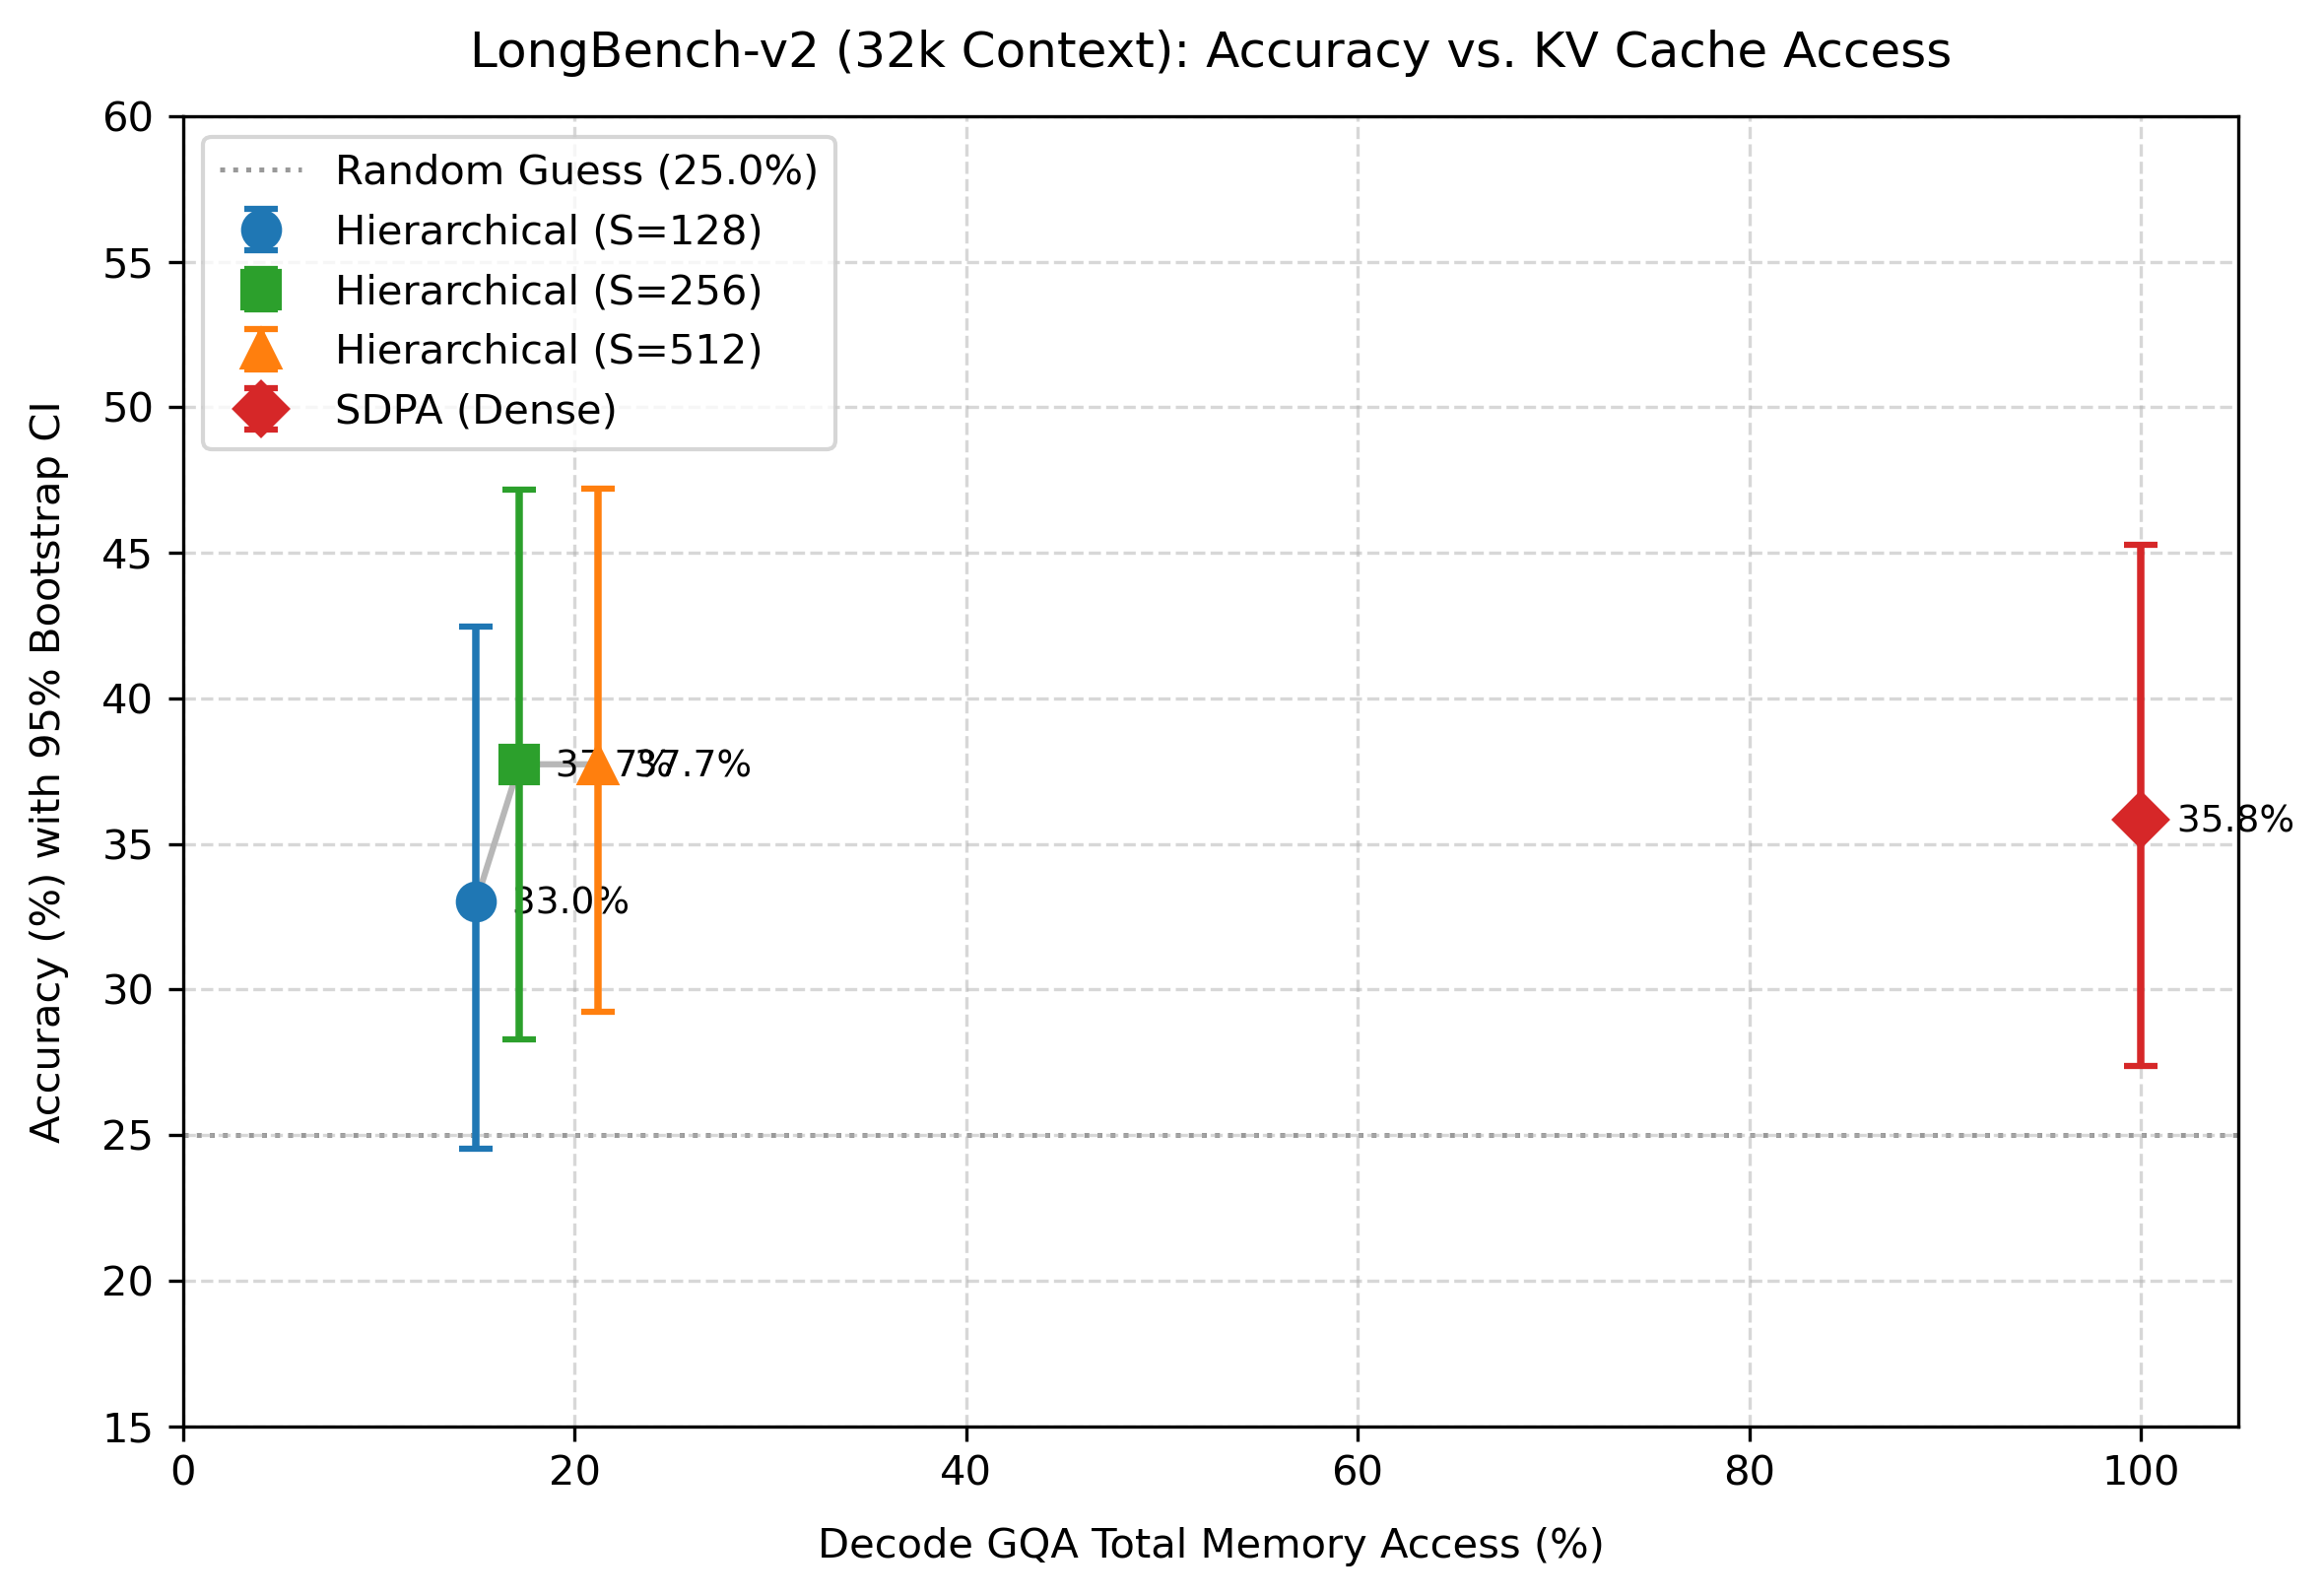

In [12]:
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Metadata and Ground Truth Setup
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
  meta_lookup = {int(k): v for k, v in json.load(f).items()}


def extract_strict_mc_choice(pred_text: str) -> str:
  """Extracts multiple-choice option (A-D) while guarding against ambiguous outputs."""
  if not pred_text:
    return ""
  # Primary Target: 'Final Answer: [X]' or 'Final Answer: X'
  final_match = re.search(
      r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
      pred_text,
      re.IGNORECASE,
  )
  if final_match:
    # Flag ambiguous guesses like [B/C]
    post_match_slice = pred_text[final_match.start() : final_match.end() + 10]
    if re.search(
        r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
        post_match_slice,
        re.IGNORECASE,
    ):
      return ""
    return final_match.group(1).upper()

  # Secondary Target: Explicit answer declarations
  explicit_match = re.search(
      r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
      pred_text,
      re.IGNORECASE,
  )
  if explicit_match:
    return explicit_match.group(1).upper()

  # Fallback: Final trailing isolated character on newline
  tail_matches = re.findall(
      r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
  )
  if tail_matches:
    return tail_matches[-1].upper()

  return ""


# 2. Define prediction files to evaluate
# Update paths to match your directory hierarchy if needed
eval_targets = [
    {
        "label": "Hierarchical (S=128)",
        "file": (
            "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "o",
        "color": "#1f77b4",
    },
    {
        "label": "Hierarchical (S=256)",
        "file": (
            "../benchmarks/longbench/hierarchical/256/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "s",
        "color": "#2ca02c",
    },
    {
        "label": "Hierarchical (S=512)",
        "file": (
            "../benchmarks/longbench/hierarchical/512/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "^",
        "color": "#ff7f0e",
    },
    {
        "label": "SDPA (Dense)",
        "file": (
            "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"
        ),
        "marker": "D",
        "color": "#d62728",
    },
]


def bootstrap_ci(
    data: np.ndarray,
    n_bootstraps: int = 2000,
    ci: float = 0.95,
    seed: int = 2026,
):
  """Computes non-parametric percentile bootstrap confidence intervals."""
  rng = np.random.default_rng(seed)
  resamples = rng.choice(data, size=(n_bootstraps, len(data)), replace=True)
  means = np.mean(resamples, axis=1) * 100.0  # Percentage
  alpha = (1.0 - ci) / 2.0
  low = np.percentile(means, 100.0 * alpha)
  high = np.percentile(means, 100.0 * (1.0 - alpha))
  return low, high


# 3. Parse runs and collect metrics
plot_data = []

for target in eval_targets:
  if not os.path.exists(target["file"]):
    print(f"Skipping {target['label']}: File not found at {target['file']}")
    continue

  scores = []
  access_pcts = []

  with open(target["file"], "r", encoding="utf-8") as f:
    for line in f:
      if not line.strip():
        continue
      entry = json.loads(line.strip())

      # Match ground truth
      idx = entry.get(
          "index",
          entry.get("others", {}).get(
              "source_position", entry.get("others", {}).get("id")
          ),
      )
      gt_answer = meta_lookup[idx]["answer"]

      # Grade prediction
      pred_choice = extract_strict_mc_choice(entry.get("pred", ""))
      score = 1.0 if (pred_choice and pred_choice == gt_answer) else 0.0
      scores.append(score)

      # Extract memory access percentage (KV data + routing overhead)
      metrics = entry.get("metrics", {})
      mem_pct = metrics.get(
          "decode_gqa_total_access_pct",
          metrics.get("decode_naive_total_access_pct", 100.0),
      )
      access_pcts.append(mem_pct)

  scores_arr = np.array(scores)
  mean_acc = np.mean(scores_arr) * 100.0
  ci_low, ci_high = bootstrap_ci(scores_arr)
  mean_access = np.mean(access_pcts)

  err_lower = mean_acc - ci_low
  err_upper = ci_high - mean_acc

  plot_data.append({
      "label": target["label"],
      "acc": mean_acc,
      "acc_err": [[err_lower], [err_upper]],
      "access": mean_access,
      "marker": target["marker"],
      "color": target["color"],
  })

  print(
      f"{target['label']:<24} | Accuracy: {mean_acc:5.1f}% [95% CI: {ci_low:5.1f}%, {ci_high:5.1f}%] | Access: {mean_access:5.1f}%"
  )

# 4. Generate Plot
plt.figure(figsize=(8, 5.5), dpi=300)
plt.grid(True, linestyle="--", alpha=0.5, zorder=0)

# Connect hierarchical points to visualize Pareto efficiency frontier
hier_pts = [p for p in plot_data if "Hierarchical" in p["label"]]
if hier_pts:
  hier_pts.sort(key=lambda x: x["access"])
  plt.plot(
      [p["access"] for p in hier_pts],
      [p["acc"] for p in hier_pts],
      linestyle="-",
      color="#888888",
      alpha=0.6,
      zorder=1,
  )

for p in plot_data:
  plt.errorbar(
      p["access"],
      p["acc"],
      yerr=p["acc_err"],
      fmt=p["marker"],
      color=p["color"],
      ecolor=p["color"],
      elinewidth=1.8,
      capsize=4,
      capthick=1.5,
      markersize=9,
      label=p["label"],
      zorder=3,
  )
  # Offset labels slightly for readability
  plt.annotate(
      f" {p['acc']:.1f}%",
      (p["access"], p["acc"]),
      textcoords="offset points",
      xytext=(6, -3),
      fontsize=9,
      fontweight="medium",
  )

# Baseline random guess reference
plt.axhline(
    y=25.0,
    color="#999999",
    linestyle=":",
    linewidth=1.2,
    label="Random Guess (25.0%)",
    zorder=1,
)

plt.title(
    "LongBench-v2 (32k Context): Accuracy vs. KV Cache Access",
    fontsize=12,
    pad=12,
)
plt.xlabel("Decode GQA Total Memory Access (%)", fontsize=10, labelpad=8)
plt.ylabel("Accuracy (%) with 95% Bootstrap CI", fontsize=10, labelpad=8)
plt.xlim(0, 105)
plt.ylim(15, max(60.0, max([p["acc"] for p in plot_data]) + 15.0))

plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()

output_png = "accuracy_vs_memory_access_ci.png"
plt.savefig(output_png)
print(f"\nPlot saved successfully to {output_png}")

C:\Users\theep\AppData\Local\Temp\ipykernel_29920\909161159.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


Readable plot saved to accuracy_vs_memory_readable.png


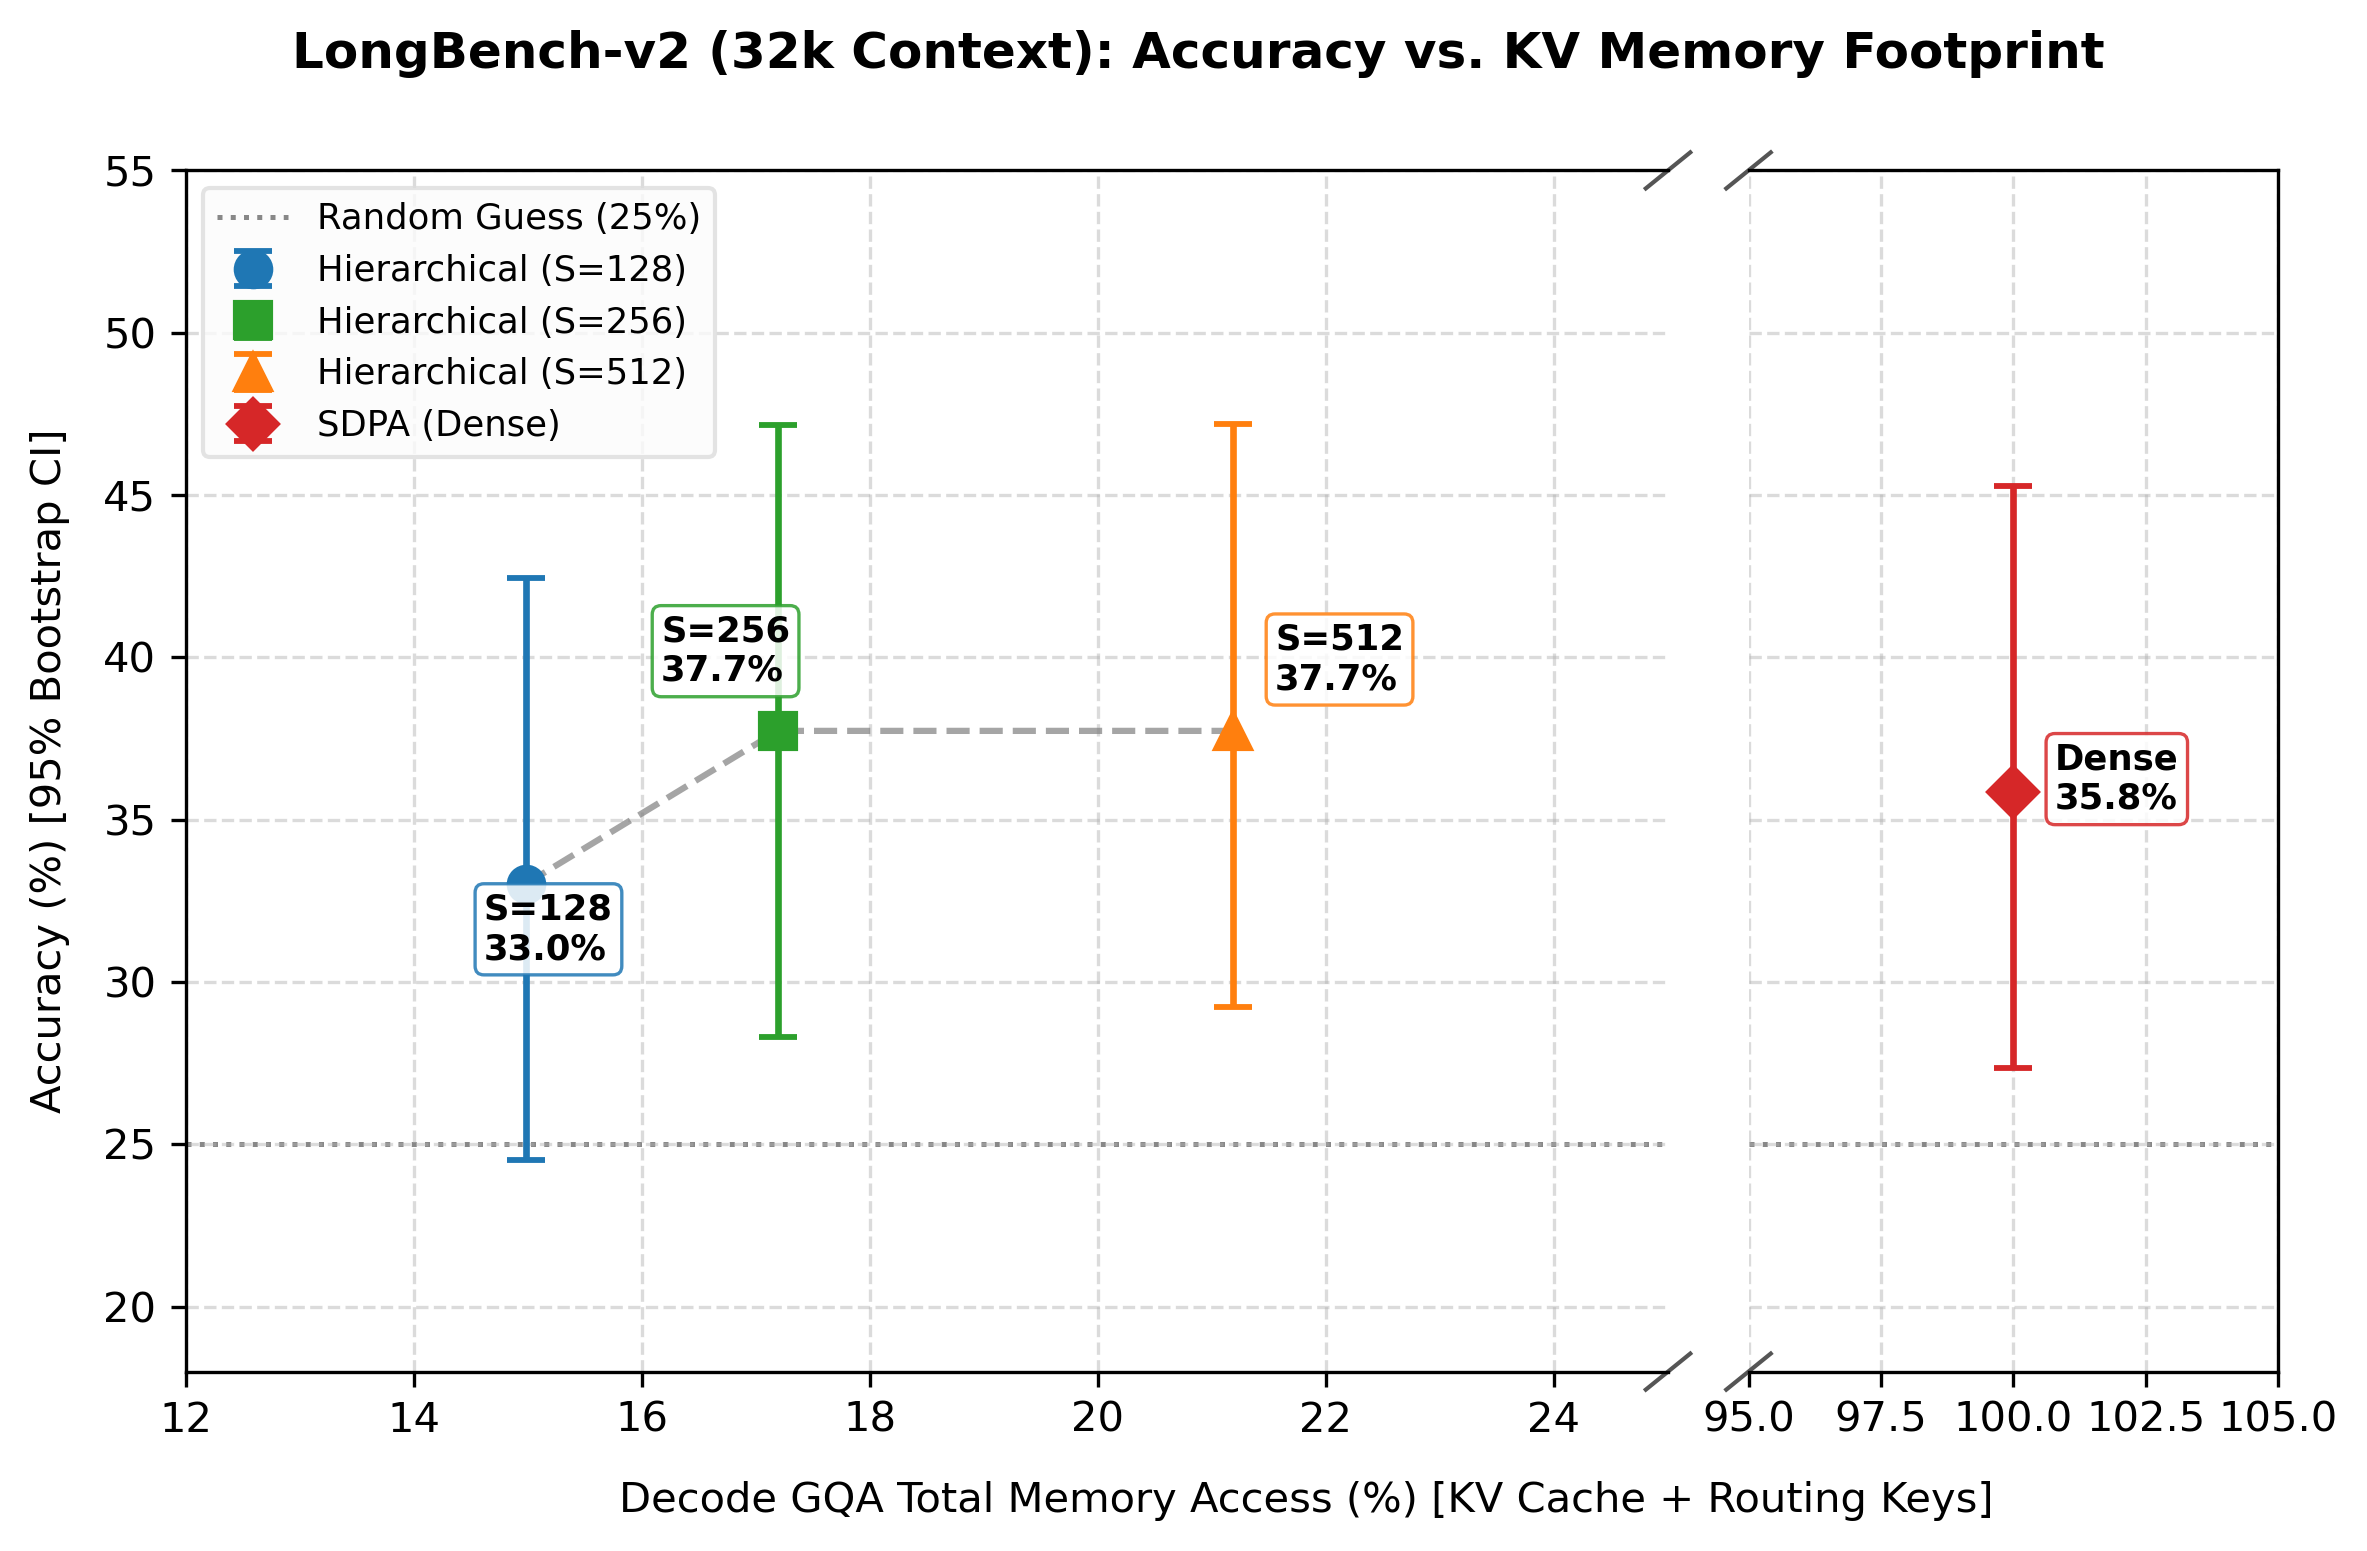

In [13]:
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Metadata setup
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
  meta_lookup = {int(k): v for k, v in json.load(f).items()}


def extract_strict_mc_choice(pred_text: str) -> str:
  if not pred_text:
    return ""
  final_match = re.search(
      r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
      pred_text,
      re.IGNORECASE,
  )
  if final_match:
    post_match_slice = pred_text[final_match.start() : final_match.end() + 10]
    if re.search(
        r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
        post_match_slice,
        re.IGNORECASE,
    ):
      return ""
    return final_match.group(1).upper()
  explicit_match = re.search(
      r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
      pred_text,
      re.IGNORECASE,
  )
  if explicit_match:
    return explicit_match.group(1).upper()
  tail_matches = re.findall(
      r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
  )
  return tail_matches[-1].upper() if tail_matches else ""


def bootstrap_ci(
    data: np.ndarray,
    n_bootstraps: int = 2000,
    ci: float = 0.95,
    seed: int = 2026,
):
  rng = np.random.default_rng(seed)
  resamples = rng.choice(data, size=(n_bootstraps, len(data)), replace=True)
  means = np.mean(resamples, axis=1) * 100.0
  alpha = (1.0 - ci) / 2.0
  return np.percentile(means, 100.0 * alpha), np.percentile(
      means, 100.0 * (1.0 - alpha)
  )


eval_targets = [
    {
        "label": "Hierarchical (S=128)",
        "file": (
            "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "o",
        "color": "#1f77b4",
        "tag": "S=128",
        "text_offset": (-10, -18),  # Shifted down-left
    },
    {
        "label": "Hierarchical (S=256)",
        "file": (
            "../benchmarks/longbench/hierarchical/256/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "s",
        "color": "#2ca02c",
        "tag": "S=256",
        "text_offset": (-28, 12),  # Shifted up-left
    },
    {
        "label": "Hierarchical (S=512)",
        "file": (
            "../benchmarks/longbench/hierarchical/512/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "^",
        "color": "#ff7f0e",
        "tag": "S=512",
        "text_offset": (10, 10),  # Shifted up-right
    },
    {
        "label": "SDPA (Dense)",
        "file": (
            "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"
        ),
        "marker": "D",
        "color": "#d62728",
        "tag": "Dense",
        "text_offset": (10, -4),
    },
]

points = []
for target in eval_targets:
  if not os.path.exists(target["file"]):
    continue
  scores, access_pcts = [], []
  with open(target["file"], "r", encoding="utf-8") as f:
    for line in f:
      if not line.strip():
        continue
      entry = json.loads(line.strip())
      idx = entry.get(
          "index",
          entry.get("others", {}).get(
              "source_position", entry.get("others", {}).get("id")
          ),
      )
      gt = meta_lookup[idx]["answer"]
      pred = extract_strict_mc_choice(entry.get("pred", ""))
      scores.append(1.0 if (pred and pred == gt) else 0.0)
      metrics = entry.get("metrics", {})
      access_pcts.append(
          metrics.get(
              "decode_gqa_total_access_pct",
              metrics.get("decode_naive_total_access_pct", 100.0),
          )
      )

  arr = np.array(scores)
  mean_acc = np.mean(arr) * 100.0
  low, high = bootstrap_ci(arr)
  points.append({
      "label": target["label"],
      "tag": target["tag"],
      "acc": mean_acc,
      "err": [[mean_acc - low], [high - mean_acc]],
      "access": np.mean(access_pcts),
      "marker": target["marker"],
      "color": target["color"],
      "offset": target["text_offset"],
  })

# 2. Broken-axis subplots (Left = Sparse zoom, Right = Dense baseline)
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(9, 5.2),
    dpi=300,
    gridspec_kw={"width_ratios": [2.8, 1], "wspace": 0.08},
)

# Plot elements on both axes
for ax in (ax1, ax2):
  ax.grid(True, linestyle="--", alpha=0.45, zorder=0)
  ax.axhline(
      25.0,
      color="#888888",
      linestyle=":",
      linewidth=1.2,
      label="Random Guess (25%)",
      zorder=1,
  )

# Draw sparse trajectory curve on left axis
hier_pts = [p for p in points if "Hierarchical" in p["label"]]
hier_pts.sort(key=lambda x: x["access"])
ax1.plot(
    [p["access"] for p in hier_pts],
    [p["acc"] for p in hier_pts],
    color="#7f7f7f",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    zorder=2,
)

# Scatter points with customized callout tags
for p in points:
  target_ax = ax1 if p["access"] < 50 else ax2
  target_ax.errorbar(
      p["access"],
      p["acc"],
      yerr=p["err"],
      fmt=p["marker"],
      color=p["color"],
      ecolor=p["color"],
      elinewidth=1.6,
      capsize=4.5,
      capthick=1.4,
      markersize=8.5,
      label=p["label"],
      zorder=4,
  )

  # Text badge with clean background patch to prevent bar occlusion
  target_ax.annotate(
      f"{p['tag']}\n{p['acc']:.1f}%",
      (p["access"], p["acc"]),
      textcoords="offset points",
      xytext=p["offset"],
      fontsize=8.5,
      fontweight="semibold",
      bbox=dict(
          boxstyle="round,pad=0.25",
          facecolor="white",
          edgecolor=p["color"],
          alpha=0.85,
          linewidth=0.8,
      ),
      zorder=5,
  )

# Set axis boundaries
ax1.set_xlim(12, 25)  # Zooms into the sparse cluster
ax2.set_xlim(95, 105)  # Targets 100% SDPA
ax1.set_ylim(18, 55)

# Broken axis visual cues (diagonal slashes)
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False)

d = 0.015
kwargs = dict(
    transform=ax1.transAxes, color="#555555", clip_on=False, linewidth=1.0
)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d * 2.8, +d * 2.8), (-d, +d), **kwargs)
ax2.plot((-d * 2.8, +d * 2.8), (1 - d, 1 + d), **kwargs)

# Titles and labels
fig.suptitle(
    "LongBench-v2 (32k Context): Accuracy vs. KV Memory Footprint",
    fontsize=12,
    fontweight="bold",
    y=0.97,
)
ax1.set_ylabel("Accuracy (%) [95% Bootstrap CI]", fontsize=10, labelpad=8)
fig.text(
    0.54,
    0.02,
    "Decode GQA Total Memory Access (%) [KV Cache + Routing Keys]",
    ha="center",
    fontsize=10,
)

# Clean legend on left plot
handles, labels = ax1.get_legend_handles_labels()
# Add Dense SDPA handle from ax2
h2, l2 = ax2.get_legend_handles_labels()
for h, l in zip(h2, l2):
  if l not in labels:
    handles.append(h)
    labels.append(l)

ax1.legend(
    handles,
    labels,
    loc="upper left",
    frameon=True,
    facecolor="#fcfcfc",
    edgecolor="#dddddd",
    fontsize=8.5,
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("accuracy_vs_memory_readable.png")
print("Readable plot saved to accuracy_vs_memory_readable.png")

C:\Users\theep\AppData\Local\Temp\ipykernel_29920\3282571465.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


Saved to accuracy_vs_memory_unified_hierarchical.png


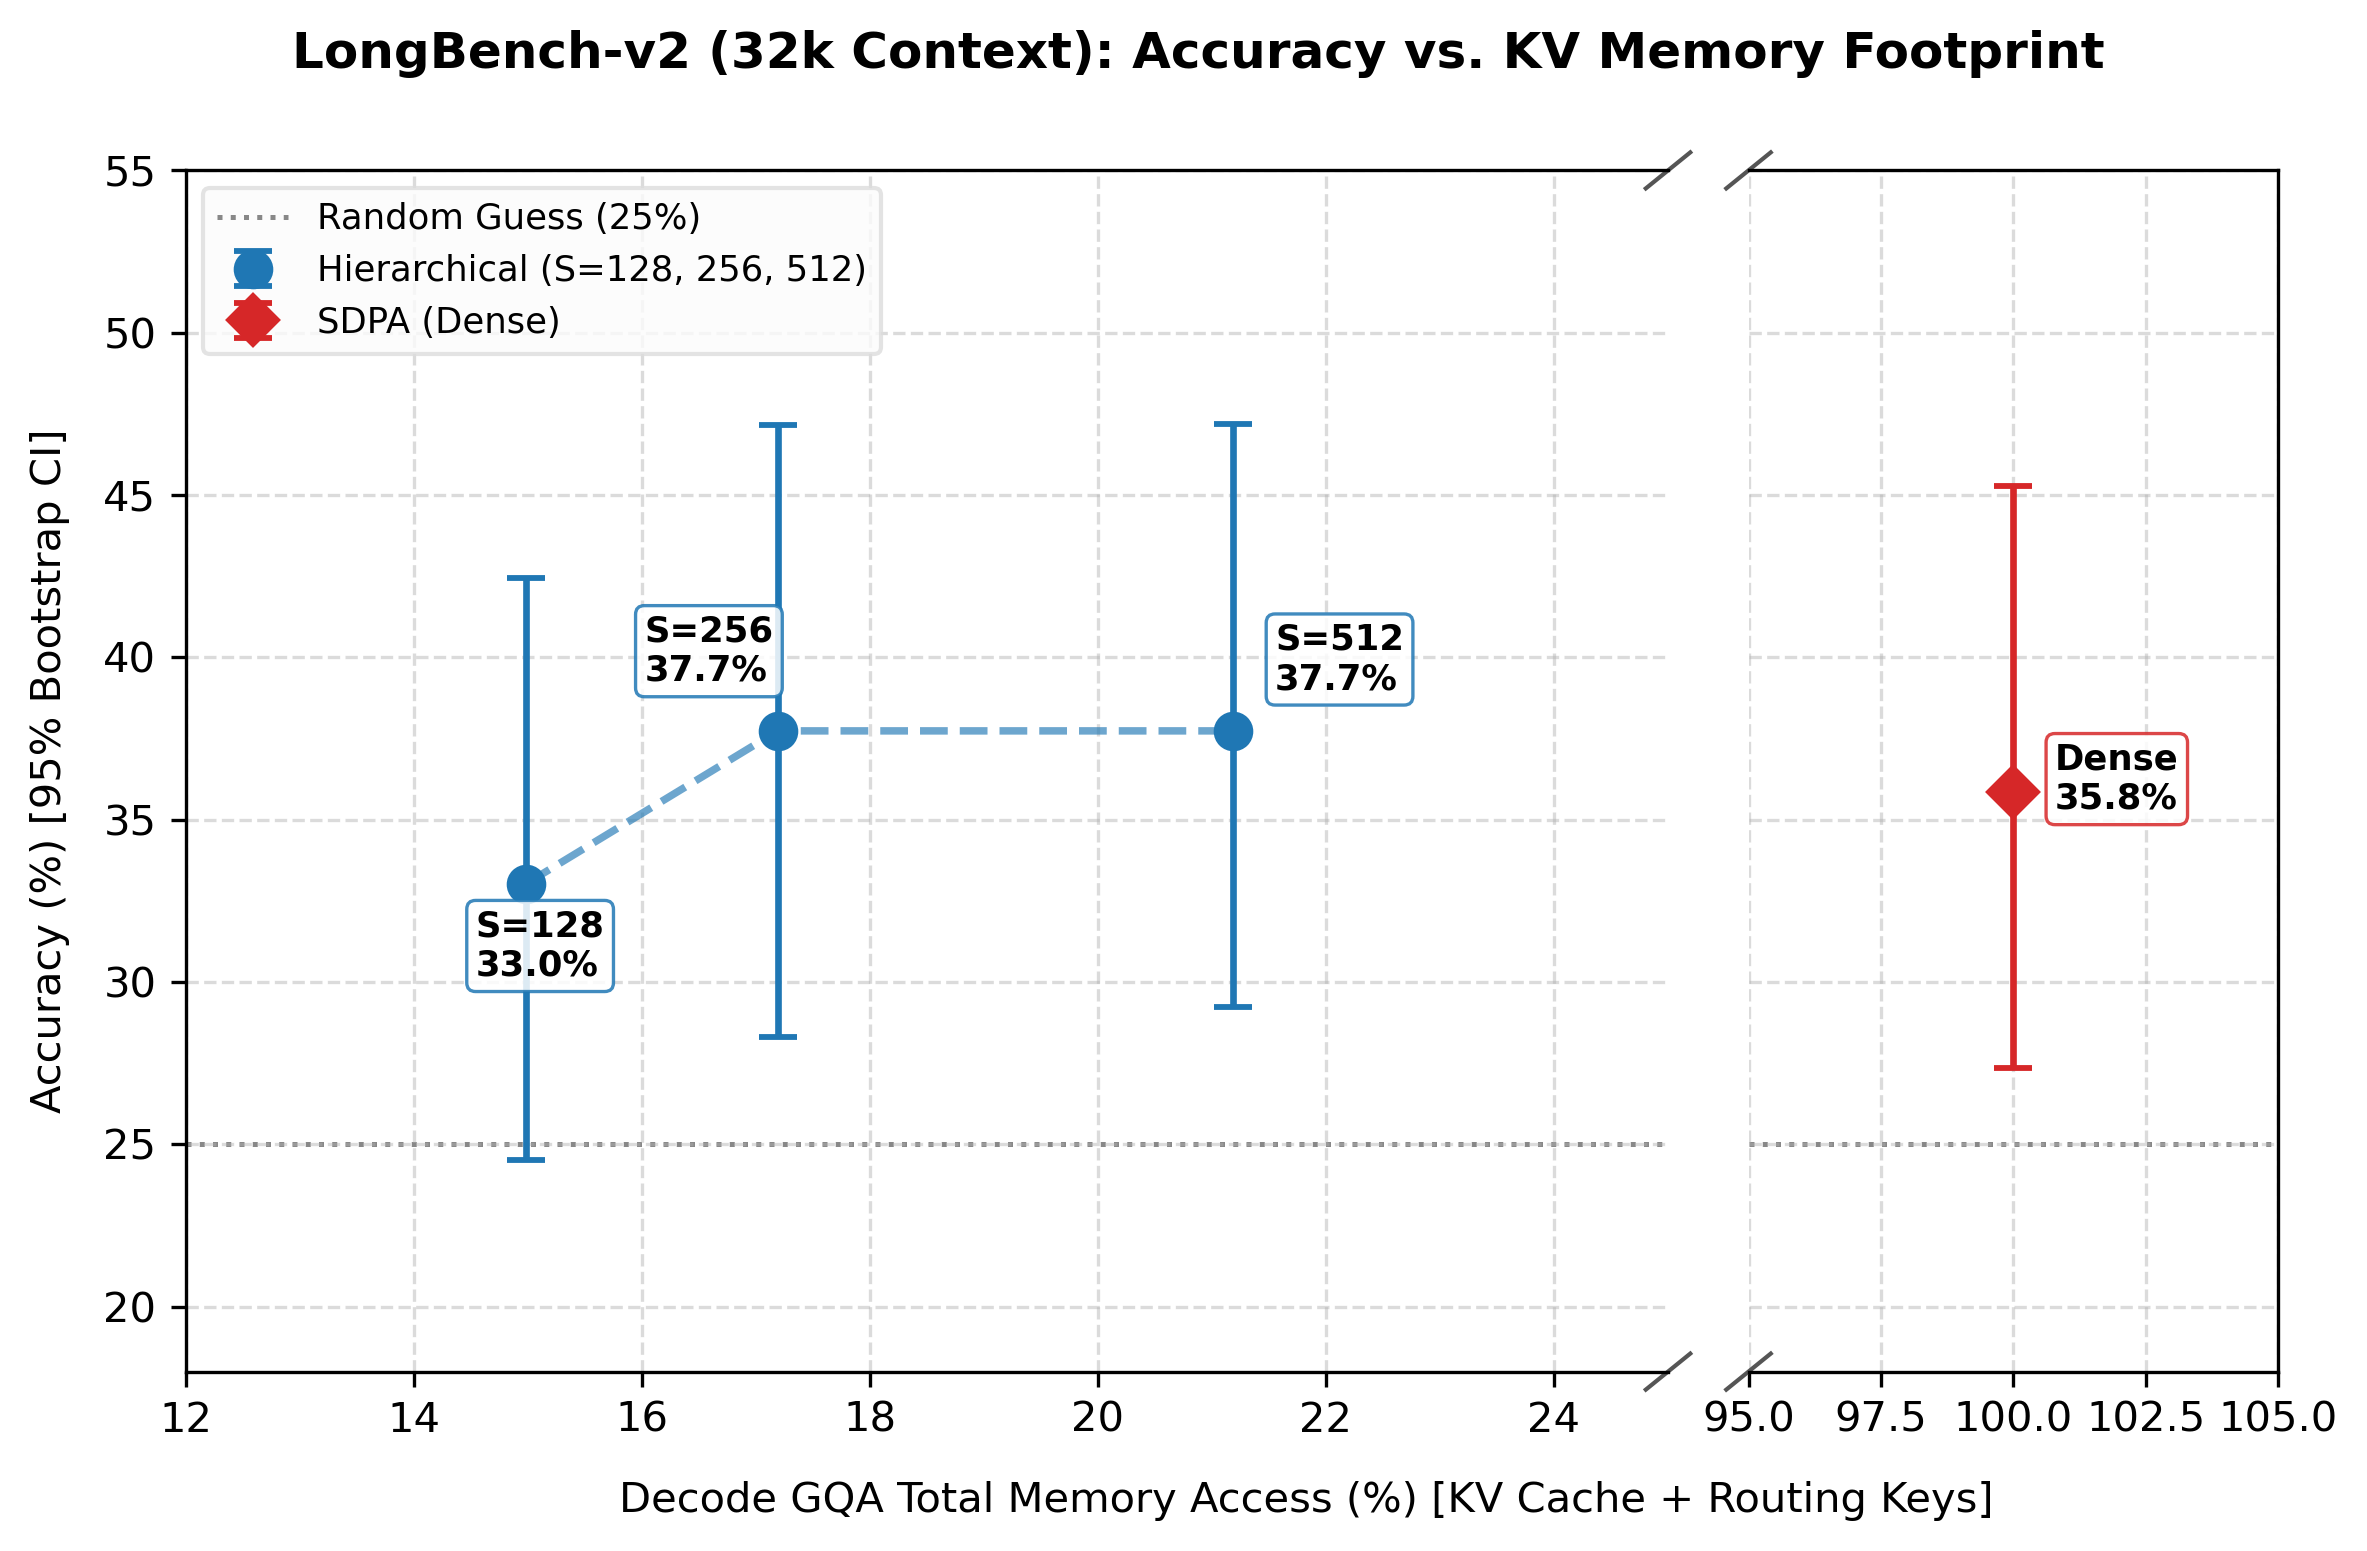

In [14]:
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Metadata setup
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
  meta_lookup = {int(k): v for k, v in json.load(f).items()}


def extract_strict_mc_choice(pred_text: str) -> str:
  if not pred_text:
    return ""
  final_match = re.search(
      r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
      pred_text,
      re.IGNORECASE,
  )
  if final_match:
    post_match_slice = pred_text[final_match.start() : final_match.end() + 10]
    if re.search(
        r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
        post_match_slice,
        re.IGNORECASE,
    ):
      return ""
    return final_match.group(1).upper()
  explicit_match = re.search(
      r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
      pred_text,
      re.IGNORECASE,
  )
  if explicit_match:
    return explicit_match.group(1).upper()
  tail_matches = re.findall(
      r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
  )
  return tail_matches[-1].upper() if tail_matches else ""


def bootstrap_ci(
    data: np.ndarray,
    n_bootstraps: int = 2000,
    ci: float = 0.95,
    seed: int = 2026,
):
  rng = np.random.default_rng(seed)
  resamples = rng.choice(data, size=(n_bootstraps, len(data)), replace=True)
  means = np.mean(resamples, axis=1) * 100.0
  alpha = (1.0 - ci) / 2.0
  return np.percentile(means, 100.0 * alpha), np.percentile(
      means, 100.0 * (1.0 - alpha)
  )


# Shared styling parameters
HIER_COLOR = "#1f77b4"
HIER_MARKER = "o"

eval_targets = [
    {
        "label": "Hierarchical (S=128, 256, 512)",
        "file": (
            "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": HIER_MARKER,
        "color": HIER_COLOR,
        "tag": "S=128",
        "text_offset": (-12, -22),
        "is_first_hier": True,
    },
    {
        "label": "Hierarchical (S=128, 256, 512)",
        "file": (
            "../benchmarks/longbench/hierarchical/256/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": HIER_MARKER,
        "color": HIER_COLOR,
        "tag": "S=256",
        "text_offset": (-32, 12),
        "is_first_hier": False,
    },
    {
        "label": "Hierarchical (S=128, 256, 512)",
        "file": (
            "../benchmarks/longbench/hierarchical/512/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": HIER_MARKER,
        "color": HIER_COLOR,
        "tag": "S=512",
        "text_offset": (10, 10),
        "is_first_hier": False,
    },
    {
        "label": "SDPA (Dense)",
        "file": (
            "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"
        ),
        "marker": "D",
        "color": "#d62728",
        "tag": "Dense",
        "text_offset": (10, -4),
        "is_first_hier": False,
    },
]

points = []
for target in eval_targets:
  if not os.path.exists(target["file"]):
    continue
  scores, access_pcts = [], []
  with open(target["file"], "r", encoding="utf-8") as f:
    for line in f:
      if not line.strip():
        continue
      entry = json.loads(line.strip())
      idx = entry.get(
          "index",
          entry.get("others", {}).get(
              "source_position", entry.get("others", {}).get("id")
          ),
      )
      gt = meta_lookup[idx]["answer"]
      pred = extract_strict_mc_choice(entry.get("pred", ""))
      scores.append(1.0 if (pred and pred == gt) else 0.0)
      metrics = entry.get("metrics", {})
      access_pcts.append(
          metrics.get(
              "decode_gqa_total_access_pct",
              metrics.get("decode_naive_total_access_pct", 100.0),
          )
      )

  arr = np.array(scores)
  mean_acc = np.mean(arr) * 100.0
  low, high = bootstrap_ci(arr)
  points.append({
      "label": target["label"],
      "tag": target["tag"],
      "acc": mean_acc,
      "err": [[mean_acc - low], [high - mean_acc]],
      "access": np.mean(access_pcts),
      "marker": target["marker"],
      "color": target["color"],
      "offset": target["text_offset"],
      "is_first_hier": target["is_first_hier"],
  })

# 2. Broken-axis layout
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(9, 5.2),
    dpi=300,
    gridspec_kw={"width_ratios": [2.8, 1], "wspace": 0.08},
)

for ax in (ax1, ax2):
  ax.grid(True, linestyle="--", alpha=0.45, zorder=0)
  ax.axhline(
      25.0,
      color="#888888",
      linestyle=":",
      linewidth=1.2,
      label="Random Guess (25%)",
      zorder=1,
  )

# Draw connecting trajectory for hierarchical series
hier_pts = [p for p in points if "Hierarchical" in p["label"]]
hier_pts.sort(key=lambda x: x["access"])
ax1.plot(
    [p["access"] for p in hier_pts],
    [p["acc"] for p in hier_pts],
    color=HIER_COLOR,
    linestyle="--",
    linewidth=1.8,
    alpha=0.65,
    zorder=2,
)

# Plot points
for p in points:
  target_ax = ax1 if p["access"] < 50 else ax2
  # Only assign a label to the first hierarchical point to avoid duplicate legend entries
  label = (
      p["label"]
      if (p["is_first_hier"] or "Hierarchical" not in p["label"])
      else None
  )

  target_ax.errorbar(
      p["access"],
      p["acc"],
      yerr=p["err"],
      fmt=p["marker"],
      color=p["color"],
      ecolor=p["color"],
      elinewidth=1.6,
      capsize=4.5,
      capthick=1.4,
      markersize=8.5,
      label=label,
      zorder=4,
  )

  # Badge annotation
  target_ax.annotate(
      f"{p['tag']}\n{p['acc']:.1f}%",
      (p["access"], p["acc"]),
      textcoords="offset points",
      xytext=p["offset"],
      fontsize=8.5,
      fontweight="semibold",
      bbox=dict(
          boxstyle="round,pad=0.25",
          facecolor="white",
          edgecolor=p["color"],
          alpha=0.85,
          linewidth=0.8,
      ),
      zorder=5,
  )

ax1.set_xlim(12, 25)
ax2.set_xlim(95, 105)
ax1.set_ylim(18, 55)

# Broken-axis spine styling
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False)

d = 0.015
kwargs = dict(
    transform=ax1.transAxes, color="#555555", clip_on=False, linewidth=1.0
)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d * 2.8, +d * 2.8), (-d, +d), **kwargs)
ax2.plot((-d * 2.8, +d * 2.8), (1 - d, 1 + d), **kwargs)

fig.suptitle(
    "LongBench-v2 (32k Context): Accuracy vs. KV Memory Footprint",
    fontsize=12,
    fontweight="bold",
    y=0.97,
)
ax1.set_ylabel("Accuracy (%) [95% Bootstrap CI]", fontsize=10, labelpad=8)
fig.text(
    0.54,
    0.02,
    "Decode GQA Total Memory Access (%) [KV Cache + Routing Keys]",
    ha="center",
    fontsize=10,
)

# Merge handles from both axes for the legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + [h for h, l in zip(handles2, labels2) if l not in labels1]
labels = labels1 + [l for l in labels2 if l not in labels1]

ax1.legend(
    handles,
    labels,
    loc="upper left",
    frameon=True,
    facecolor="#fcfcfc",
    edgecolor="#dddddd",
    fontsize=8.5,
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("accuracy_vs_memory_unified_hierarchical.png")
print("Saved to accuracy_vs_memory_unified_hierarchical.png")